<a href="https://colab.research.google.com/github/Jnanesh2005/4NI23CI043-Jnanesh_M_J-ML_Lab_2/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RIPPER/CN2 STYLE RULES
----------------------
IF Temperature = Hot AND Wind = Weak THEN Sport = Yes
IF Temperature = Cold AND Wind = Weak THEN Sport = Yes
IF Temperature = Mild AND Wind = Strong THEN Sport = Yes
IF Temperature = Mild AND Wind = Weak THEN Sport = Yes
Wind = Weak -> FOIL Gain = 1.755
Wind = Strong -> FOIL Gain = -1.000
Temperature = Hot -> FOIL Gain = -0.415
Temperature = Cold -> FOIL Gain = -0.415
Temperature = Mild -> FOIL Gain = 1.170

BEST FOIL RULE
--------------
IF Wind = Weak THEN Sport = Yes


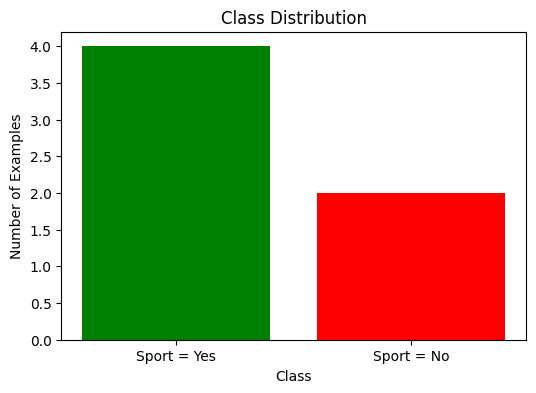

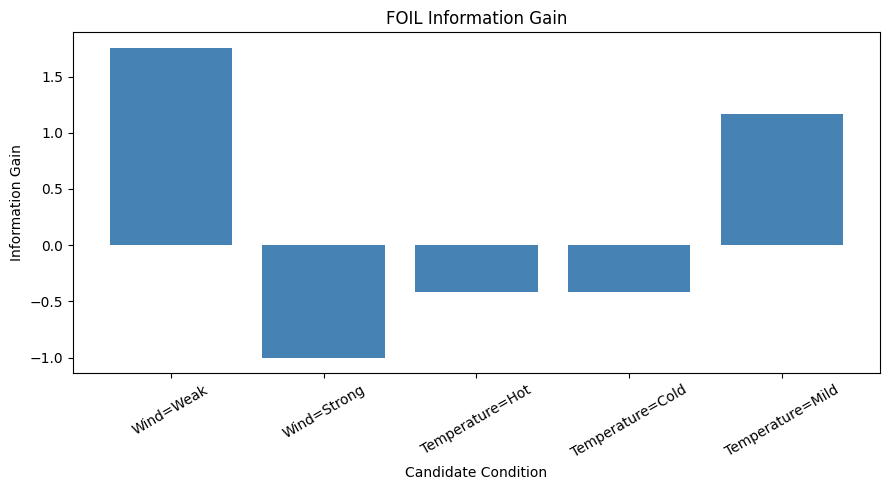

In [2]:
import math
import matplotlib.pyplot as plt


data = [
    {"Temperature": "Hot",  "Wind": "Strong", "Sport": "No"},
    {"Temperature": "Hot",  "Wind": "Weak",   "Sport": "Yes"},
    {"Temperature": "Cold", "Wind": "Strong", "Sport": "No"},
    {"Temperature": "Cold", "Wind": "Weak",   "Sport": "Yes"},
    {"Temperature": "Mild", "Wind": "Strong", "Sport": "Yes"},
    {"Temperature": "Mild", "Wind": "Weak",   "Sport": "Yes"}
]


def generate_rules(data):
    rules = []

    for row in data:
        if row["Sport"] == "Yes":
            rule = (
                f"IF Temperature = {row['Temperature']} "
                f"AND Wind = {row['Wind']} "
                f"THEN Sport = Yes"
            )

            if rule not in rules:
                rules.append(rule)

    return rules


print("RIPPER/CN2 STYLE RULES")
print("----------------------")

rules = generate_rules(data)

for rule in rules:
    print(rule)



positive = [
    ("Hot", "Weak"),
    ("Cold", "Weak"),
    ("Mild", "Strong"),
    ("Mild", "Weak")
]

negative = [
    ("Hot", "Strong"),
    ("Cold", "Strong")
]


def foil_gain(p0, n0, p1, n1):

    if p1 == 0:
        return 0

    if n1 == 0:
        return p1 * (
            math.log2(p1 / p1) -
            math.log2(p0 / (p0 + n0))
        )

    return p1 * (
        math.log2(p1 / (p1 + n1)) -
        math.log2(p0 / (p0 + n0))
    )


conditions = [
    ("Wind", "Weak"),
    ("Wind", "Strong"),
    ("Temperature", "Hot"),
    ("Temperature", "Cold"),
    ("Temperature", "Mild")
]

gains = []

p0 = len(positive)
n0 = len(negative)

for attribute, value in conditions:

    p1 = 0
    n1 = 0

    for temperature, wind in positive:
        if attribute == "Temperature" and temperature == value:
            p1 += 1
        elif attribute == "Wind" and wind == value:
            p1 += 1

    for temperature, wind in negative:
        if attribute == "Temperature" and temperature == value:
            n1 += 1
        elif attribute == "Wind" and wind == value:
            n1 += 1

    gain = foil_gain(p0, n0, p1, n1)
    gains.append(gain)

    print(
        f"{attribute} = {value} -> "
        f"FOIL Gain = {gain:.3f}"
    )


best_index = gains.index(max(gains))
best_condition = conditions[best_index]

print("\nBEST FOIL RULE")
print("--------------")
print(
    f"IF {best_condition[0]} = {best_condition[1]} "
    f"THEN Sport = Yes"
)



yes_count = sum(1 for row in data if row["Sport"] == "Yes")
no_count = sum(1 for row in data if row["Sport"] == "No")

plt.figure(figsize=(6, 4))

plt.bar(
    ["Sport = Yes", "Sport = No"],
    [yes_count, no_count],
    color=["green", "red"]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Examples")

plt.show()



labels = [
    f"{a}={v}"
    for a, v in conditions
]

plt.figure(figsize=(9, 5))

plt.bar(
    labels,
    gains,
    color="steelblue"
)

plt.title("FOIL Information Gain")
plt.xlabel("Candidate Condition")
plt.ylabel("Information Gain")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()